## Pluvial Floods Model V1

Imports

In [ ]:
import requests
import pandas as pd
from datetime import datetime, timedelta, timezone
from zoneinfo import ZoneInfo
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, f1_score
import os

#### 1. Explore ways to get meterological data

In [ ]:
BASE_URL = "https://api.weather.gc.ca/collections/swob-realtime/items"

# Montreal bounding box
# lon_min, lat_min, lon_max, lat_max
MONTREAL_BBOX = "-74.3,45.3,-73.2,45.8"

def get_all_montreal_observations():
    obs_list = []
    time_now = datetime.now(timezone.utc)
    time_start = time_now - timedelta(hours=24)

    time_str = f"{time_start.strftime('%Y-%m-%dT%H:%M:%SZ')}/{time_now.strftime('%Y-%m-%dT%H:%M:%SZ')}"

    params = {
        "bbox": MONTREAL_BBOX,
        "datetime": time_str,
        "limit": 10000,
        "f": "json"
    }
    res = requests.get(BASE_URL, params=params)
    res.raise_for_status()
    features = res.json()["features"]
    print(f"{len(features)} observations found")

    for f in features:
        p = f["properties"]

        obs_list.append({
            "station": p.get("station_name"),
            "temp": p.get("air_temp"),
            "precip": p.get("precip_amt_lst_hr", 0),
            "snow": p.get("snow_depth", None),
        })

    if not obs_list:
        return None

    df = pd.DataFrame(obs_list)

    stats = {
        "Temp max.(°C)": df["temp"].max(),
        "Temp min.(°C)": df["temp"].min(),
        "Temp moy.(°C)": df["temp"].mean(),
        "Précip. tot. (mm)": df["precip"].sum(),
        "Neige au sol (cm)": df["snow"].mean(),
        "Stations used": df["station"].nunique()
    }
    return stats

# Execute
stats = get_all_montreal_observations()

if stats:
    final = {
        "Date": datetime.now().strftime("%Y-%m-%d"),
        "Temp max.(°C)": round(stats["Temp max.(°C)"],1),
        "Temp min.(°C)": round(stats["Temp min.(°C)"],1),
        "Temp moy.(°C)": round(stats["Temp moy.(°C)"],1),
        "Précip. tot. (mm)": round(stats["Précip. tot. (mm)"],1),
        "Neige au sol (cm)": round(stats["Neige au sol (cm)"],1),
        "Stations": stats["Stations used"]
    }

    print(final)
else:
    print("No data")


4462 observations found
{'Date': '2026-02-19', 'Temp max.(°C)': np.float64(-0.4), 'Temp min.(°C)': np.float64(-15.3), 'Temp moy.(°C)': np.float64(-5.6), 'Précip. tot. (mm)': np.int64(0), 'Neige au sol (cm)': nan, 'Stations': 0}


In [ ]:
# Step 3: Alternative - Get hourly observations (more current)
# For real-time data, use the SWOB (Surface Weather Observations) endpoint
swob_url = "https://api.weather.gc.ca/collections/swob-realtime/items"

now = datetime.now(timezone.utc)
yesterday = now - timedelta(days=1)

params = {
    'bbox': '-73.9,45.4,-73.5,45.7',
    'limit': 50,
    'sortby': '-obs_date_tm',  
    'f': 'json'
}

response = requests.get(swob_url, params=params)
swob_data = response.json()
print("\nRecent observations:")
for feature in swob_data.get('features', [])[:5]:  # Show first 5
    props = feature['properties']
    obs_time = props.get('obs_date_tm')
    if obs_time != 'N/A':
        dt_utc = datetime.fromisoformat(obs_time.replace('Z', '+00:00'))
        eastern_time = dt_utc.astimezone(ZoneInfo("US/Eastern"))
        time_str = eastern_time.strftime('%Y-%m-%d %I:%M %p %Z')
    else:
        time_str = 'N/A'
    print(f"\nStation: {props.get('stn_nam-value', 'N/A')}")
    print(f"Climate ID: {props.get('clim_id-value', 'N/A')}")
    print(f"Time: {time_str}")
    print(f"Precipitation (1hr): {props.get('pcpn_amt_pst1hr', 'N/A')} mm")
    print(f"Air temp: {props.get('air_temp', 'N/A')}°C")


Recent observations:

Station: MCTAVISH
Climate ID: 7024745
Time: 2026-02-19 08:59 AM EST
Precipitation (1hr): 0 mm
Air temp: -6.7°C

Station: MCTAVISH
Climate ID: 7024745
Time: 2026-02-19 08:58 AM EST
Precipitation (1hr): 0 mm
Air temp: -6.8°C

Station: MONTREAL/PIERRE ELLIOTT TRUDEAU INTL
Climate ID: 702S006
Time: 2026-02-19 08:58 AM EST
Precipitation (1hr): 0 mm
Air temp: -5.4°C

Station: MONTREAL/PIERRE ELLIOTT TRUDEAU INTL
Climate ID: 702S006
Time: 2026-02-19 08:57 AM EST
Precipitation (1hr): 0 mm
Air temp: -5.6°C

Station: MCTAVISH
Climate ID: 7024745
Time: 2026-02-19 08:57 AM EST
Precipitation (1hr): 0 mm
Air temp: -6.7°C


In [ ]:
GEOMET_WMS_BASE = "https://geo.weather.gc.ca/geomet/"

LAYERS = {
    "temperature": "GDPS.ETA_TT",
    "humidity": "GDPS.ETA_HR",
    "precipitation_24h": "RDPA.24F_PR",
}

lat = 45.5017
lng = -73.5673


def get_feature_info(lat, lng, layer):

    delta = 0.02
    bbox = f"{lat-delta},{lng-delta},{lat+delta},{lng+delta}"

    params = {
        "SERVICE": "WMS",
        "VERSION": "1.3.0",
        "REQUEST": "GetFeatureInfo",
        "LAYERS": layer,
        "QUERY_LAYERS": layer,
        "CRS": "EPSG:4326",
        "BBOX": bbox,
        "WIDTH": 10,
        "HEIGHT": 10,
        "I": 5,
        "J": 5,
        "INFO_FORMAT": "application/json",
    }

    r = requests.get(GEOMET_WMS_BASE, params=params)

    r.raise_for_status()

    data = r.json()

    return data


results = {}

for name, layer in LAYERS.items():

    data = get_feature_info(lat, lng, layer)

    try:
        value = data["features"][0]["properties"]["value"]
    except:
        value = None

    results[name] = value


df = pd.DataFrame([results])

display(df)

print("\nSummary")
print("Temperature:", results["temperature"], "°C")
print("Humidity:", results["humidity"], "%")
print("Total precipitation next 24h:", results["precipitation_24h"], "mm")


,temperature,humidity,precipitation_24h
0,-9.845343,78,0.023



Summary
Temperature: -9.8453426 °C
Humidity: 78 %
Total precipitation next 24h: 0.023000002 mm


#### 2. Create flood CSV: weather_with_floods_2015_2026.csv

In [ ]:
years = range(2015, 2027)

numeric_cols = [
    "Temp max.(°C)",
    "Temp min.(°C)",
    "Temp moy.(°C)",
    "Précip. tot. (mm)",
    "Neige au sol (cm)"
]

columns_to_keep = ["Date/Heure"] + numeric_cols

stations = [
    "702S006",  # Montreal-Trudeau
    "7025251"  # MONTREAL INTL A
]

df_list = []

for year in years:
    station_dfs = []

    for station in stations:
        file_path = f"/weather_data/yearly_data/fr_climat_quotidiennes_QC_{station}_{year}_P1D.csv"
        
        if not os.path.exists(file_path):
            continue

        df = pd.read_csv(file_path)[columns_to_keep]

        # Clean numeric columns
        df[numeric_cols] = (
            df[numeric_cols]
            .astype(str)
            .apply(lambda col: col.str.replace(",", ".", regex=False))
            .apply(pd.to_numeric, errors="coerce")
        )

        station_dfs.append(df)

    if station_dfs:
        combined = pd.concat(station_dfs)

        # Average between stations for that year
        averaged = combined.groupby("Date/Heure", as_index=False)[numeric_cols].mean().round(1)

        df_list.append(averaged)

weather_df = pd.concat(df_list, ignore_index=True) # Combine all years

# Date processing
weather_df["Date/Heure"] = pd.to_datetime(weather_df["Date/Heure"])
weather_df = weather_df.sort_values("Date/Heure").reset_index(drop=True)

# Cutoff date
weather_df = weather_df[
    weather_df["Date/Heure"] <= pd.Timestamp.today().normalize() - pd.Timedelta(days=1)
]

# Interpolate missing values
cols_to_fill = ["Temp moy.(°C)", "Précip. tot. (mm)"]

weather_df[cols_to_fill] = weather_df[cols_to_fill].interpolate(
    method="linear",
    limit_direction="both"
)

pluvial_dates = ["2016-08-16", "2019-10-01", "2019-10-17", "2019-10-31", "2022-06-16",
    "2022-09-13", "2023-07-13", "2023-10-07", "2024-07-10", "2024-08-09", "2025-07-13"]

river_dates = ["2017-05-01", "2019-04-26", "2023-05-03"]

weather_df["Inondation pluviale"] = (
    weather_df["Date/Heure"]
    .isin(pd.to_datetime(pluvial_dates))
    .astype(int)
)

weather_df["Crue fluviale"] = (
    weather_df["Date/Heure"]
    .isin(pd.to_datetime(river_dates))
    .astype(int)
)

# ---- Save ----
output_path = "/weather_data/weather_with_floods_2015_2026.csv"
weather_df.to_csv(output_path, index=False)

print(f"File saved to {output_path}")

File saved to ../../weather_data/weather_with_floods_2015_2026.csv


#### 3. Read and analyze CSV

In [7]:
file_path = "../../server/app/data/weather_with_floods_2015_2026.csv"
weather_df = pd.read_csv(file_path)
weather_df["Date/Heure"] = pd.to_datetime(weather_df["Date/Heure"])


In [8]:
print("Missing values:")
print(weather_df[["Temp moy.(°C)", "Précip. tot. (mm)"]].isna().sum())


Missing values:
Temp moy.(°C)        0
Précip. tot. (mm)    0
dtype: int64


In [ ]:
def convert_to_num(df, column_name):
    if pd.api.types.is_numeric_dtype(df[column_name]):
        return df

    df[column_name] = (
        df[column_name]
        .str.replace(",", ".", regex=False)  # handle comma decimals
        .str.strip()                         # remove spaces
    )
    df[column_name] = pd.to_numeric(df[column_name], errors="coerce")
    return df

def plot_variable_with_floods(df, variable_name):
    # Ensure numeric
    # if variable_name in ["Précip. tot. (mm)", "Temp moy.(°C)", "Temp max.(°C)", "Temp min.(°C)", "Neige au sol (cm)"]:
    #     df = convert_to_num(df, variable_name)

    plot_df = df.copy()
    
    min_val = plot_df[variable_name].min()
    max_val = plot_df[variable_name].max()
    margin = (max_val - min_val) * 0.05

    plt.figure(figsize=(12, 5))

    rain_vars = ["Précip. tot. (mm)", "Rain_1d", "Rain_3d", "Rain_5d", "Rain_7d", "Rain_intensity"]
    if variable_name in rain_vars:
        plot_df = plot_df[plot_df["Temp moy.(°C)"] > 0] # Filter out precipitation where mean temp <= 0
        plt.bar(plot_df["Date/Heure"], plot_df[variable_name], label=variable_name, width=10)
        plt.ylim(min_val, max_val + margin)

    else:
        plt.plot(plot_df["Date/Heure"], plot_df[variable_name], label=variable_name)
        plt.ylim(min_val - margin, max_val + margin)

    plt.scatter(plot_df.loc[plot_df["Inondation pluviale"]==1, "Date/Heure"],
                plot_df.loc[plot_df["Inondation pluviale"]==1, variable_name],
                color="red", label="Inondation pluviale", zorder=5)
    plt.scatter(plot_df.loc[plot_df["Crue fluviale"]==1, "Date/Heure"],
                plot_df.loc[plot_df["Crue fluviale"]==1, variable_name],
                color="orange", label="Crue fluviale", zorder=5)

    plt.xlabel("Date/Heure")
    plt.ylabel(variable_name)
    plt.title(f"{variable_name} avec les événements d'inondation (2015–2026)")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [12]:
# weather_df = convert_to_num(weather_df, "Précip. tot. (mm)")
# weather_df = convert_to_num(weather_df, "Temp moy.(°C)")
weather_df["Rain_1d"] = weather_df["Précip. tot. (mm)"]
weather_df["Rain_3d"] = weather_df["Précip. tot. (mm)"].rolling(3).sum()
weather_df["Rain_5d"] = weather_df["Précip. tot. (mm)"].rolling(5).sum()
weather_df["Rain_7d"] = weather_df["Précip. tot. (mm)"].rolling(7).sum()

# Melt index to detect rise in water level
weather_df["Temp_pos"] = weather_df["Temp moy.(°C)"].clip(lower=0)
weather_df["Melt_Index"] = weather_df["Temp_pos"] * weather_df["Neige au sol (cm)"]
weather_df["Melt_3d"] = weather_df["Melt_Index"].rolling(3).sum()

# Variation in temperature
weather_df["Temp_diff_2d"] = weather_df["Temp moy.(°C)"] - weather_df["Temp moy.(°C)"].shift(2)
weather_df["Rain_intensity"] = weather_df["Rain_1d"] / (weather_df["Rain_7d"] + 1)

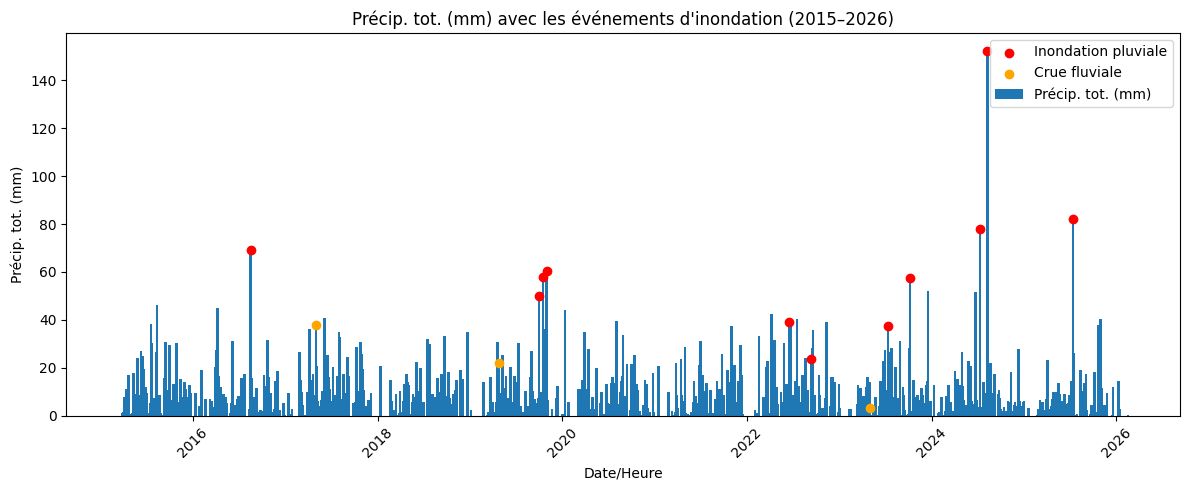

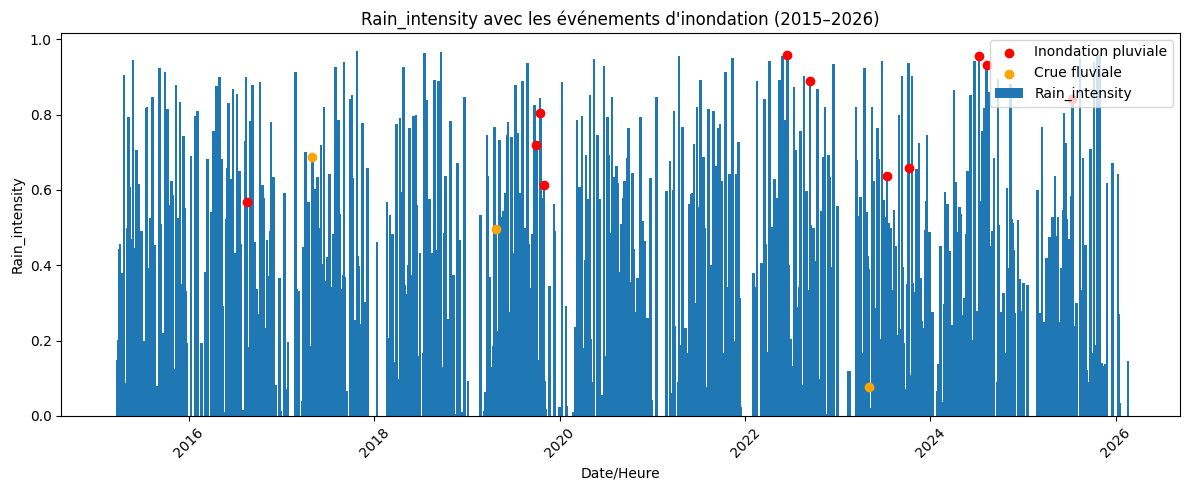

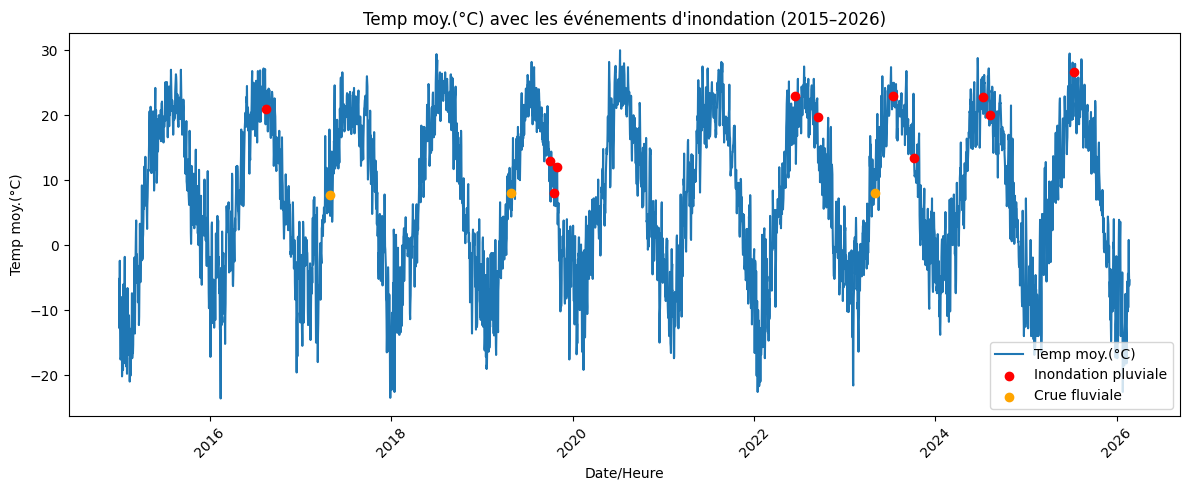

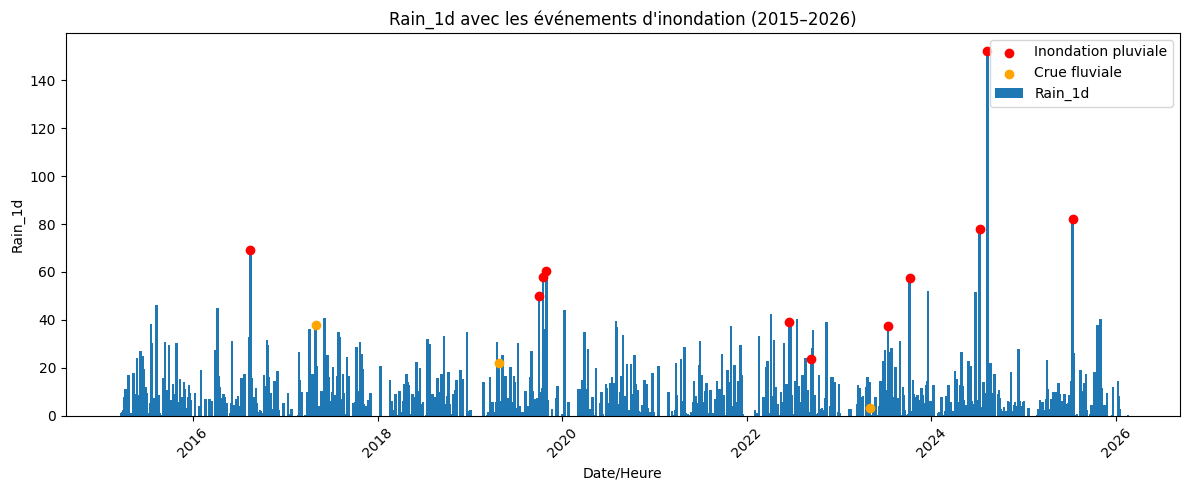

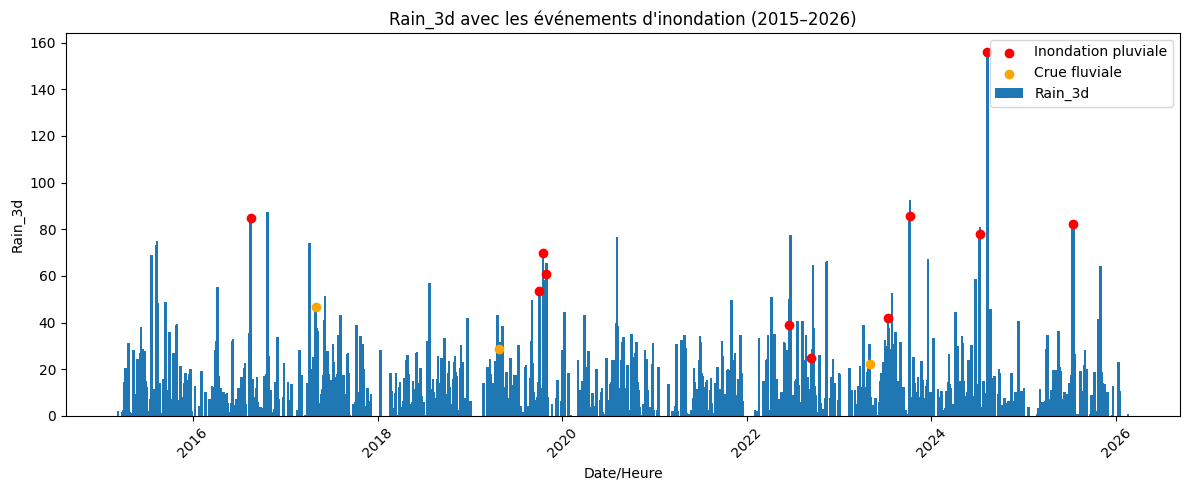

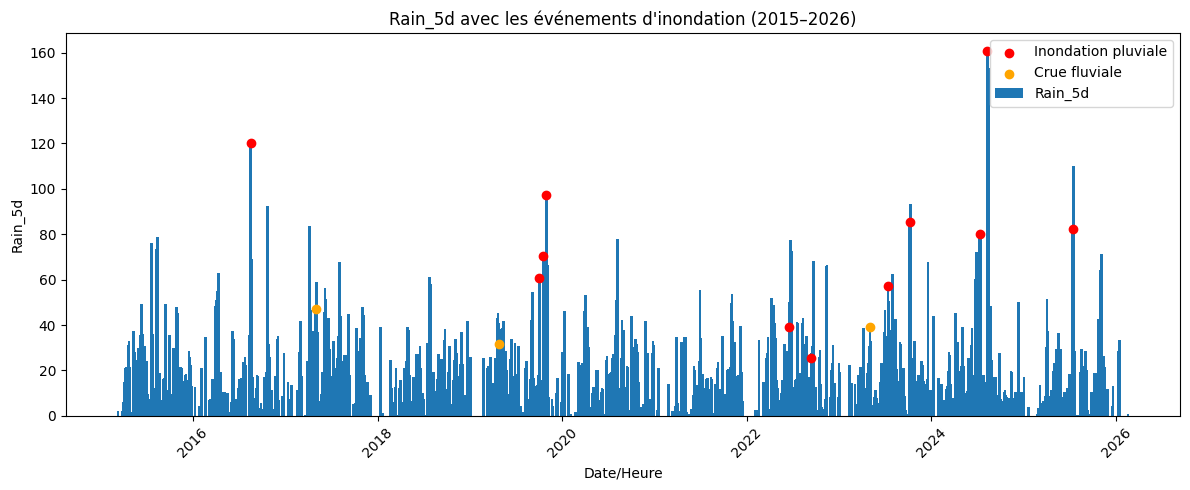

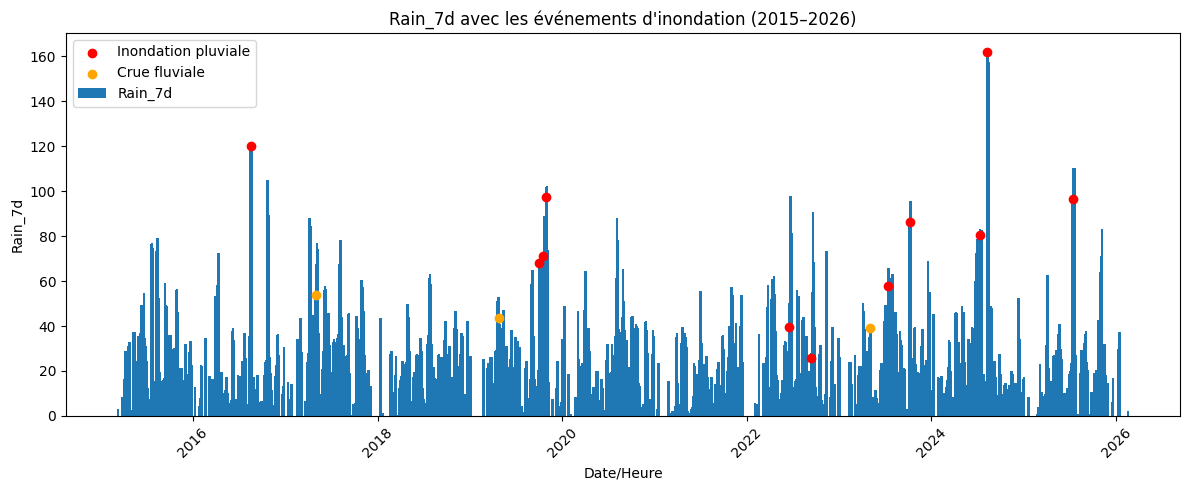

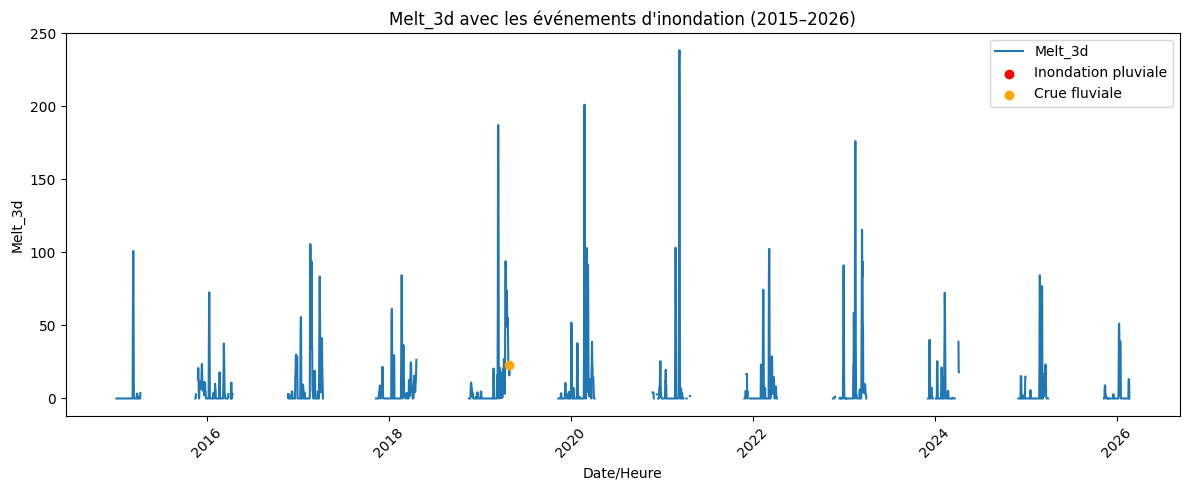

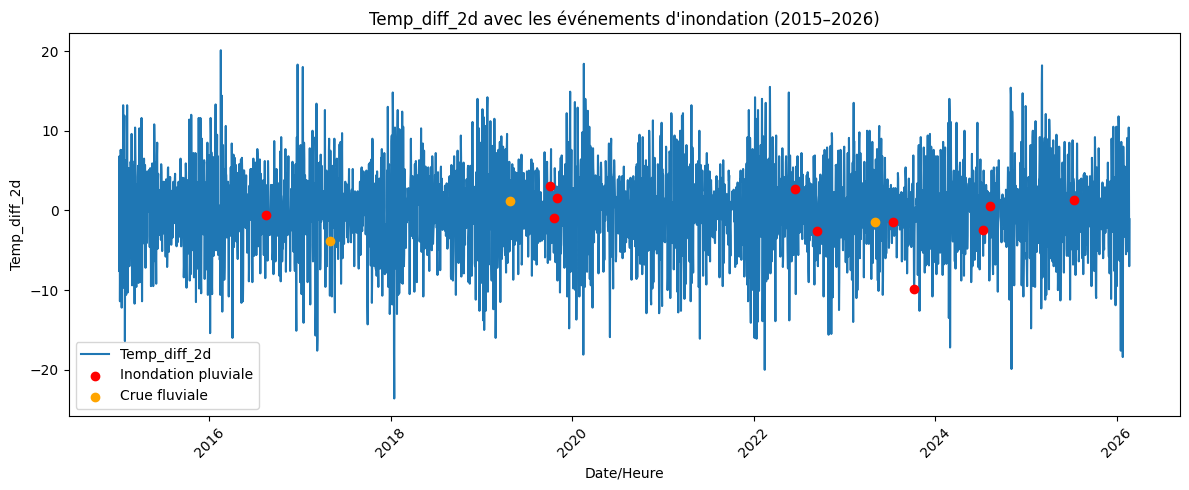

In [13]:
plot_variable_with_floods(weather_df, "Précip. tot. (mm)")
plot_variable_with_floods(weather_df, "Rain_intensity")
plot_variable_with_floods(weather_df, "Temp moy.(°C)")
plot_variable_with_floods(weather_df, "Rain_1d")
plot_variable_with_floods(weather_df, "Rain_3d")
plot_variable_with_floods(weather_df, "Rain_5d")
plot_variable_with_floods(weather_df, "Rain_7d")
plot_variable_with_floods(weather_df, "Melt_3d")
plot_variable_with_floods(weather_df, "Temp_diff_2d")


In [14]:
top_precip = weather_df.sort_values("Précip. tot. (mm)", ascending=False)
# Display top 10 highest precipitation days with Flood info
print(top_precip[["Date/Heure", "Précip. tot. (mm)", "Inondation pluviale", "Crue fluviale"]].head(20))

     Date/Heure  Précip. tot. (mm)  Inondation pluviale  Crue fluviale
3508 2024-08-09              152.1                    1              0
3846 2025-07-13               82.2                    1              0
3478 2024-07-10               78.1                    1              0
593  2016-08-16               69.0                    1              0
1764 2019-10-31               60.4                    1              0
1750 2019-10-17               58.0                    1              0
3201 2023-10-07               57.3                    1              0
3273 2023-12-18               52.1                    0              0
3461 2024-06-23               51.6                    0              0
1734 2019-10-01               49.8                    1              0
222  2015-08-11               46.4                    0              0
462  2016-04-07               44.9                    0              0
1836 2020-01-11               44.3                    0              0
2653 2

#### 4. Modèle 1 - Inondations pluviales

In [9]:
class StratifiedTimeSeriesSplit:
    def __init__(self, n_splits, min_train_pos=3, min_test_pos=3):
            self.n_splits = n_splits
            self.min_train_pos = min_train_pos
            self.min_test_pos = min_test_pos

    def split(self, y): # Folds are expanding window: example: fold 1: train[0:20%], test[20:40%], fold 2: train[0:40%], test[40:60%], etc.
        y = np.array(y)
        n_samples = len(y)
        fold_size = n_samples // (self.n_splits + 1)

        for i in range(self.n_splits):
            train_end = (i + 1) * fold_size
            test_end = train_end + fold_size if i < self.n_splits - 1 else n_samples

            # Expand TRAIN if needed

            while (train_end < n_samples and np.sum(y[:train_end]) < self.min_train_pos):
                train_end += 1


            # Expand TEST if needed
            while (test_end < n_samples and np.sum(y[train_end:test_end]) < self.min_test_pos):
                test_end += 1

            if train_end >= test_end:
                break

            train_idx = np.arange(0, train_end)
            test_idx = np.arange(train_end, test_end)

            if np.sum(y[test_idx]) == 0:
                future_pos = np.where(y[train_end:] == 1)[0]

                if len(future_pos) > 0:
                    first_pos = future_pos[0] + train_end
                    test_idx = np.arange(train_end, first_pos + 1)

            yield train_idx, test_idx

In [32]:
# 1. Preprocessing
file_path = "../../server/app/data/weather_with_floods_2015_2026.csv"
weather_df = pd.read_csv(file_path)
weather_df["Date/Heure"] = pd.to_datetime(weather_df["Date/Heure"])

df = weather_df.copy()

# Add season
df["Month"] = df["Date/Heure"].dt.month
def get_season(month):
    if month in [12, 1, 2]: return "winter"
    if month in [3, 4, 5]: return "spring"
    if month in [6, 7, 8]: return "summer"
    return "fall"

df["Season"] = df["Month"].apply(get_season)

# Compute rolling rain features
df = df.sort_values("Date/Heure").reset_index(drop=True)
df["rain_1d"] = df["Précip. tot. (mm)"]
df["rain_3d"] = df["Précip. tot. (mm)"].rolling(3, min_periods=1).sum()
df["rain_5d"] = df["Précip. tot. (mm)"].rolling(5, min_periods=1).sum()
df["rain_7d"] = df["Précip. tot. (mm)"].rolling(7, min_periods=1).sum()
df["rain_intensity"] = df["rain_1d"] / (df["rain_7d"] + 1)
df["is_freezing"] = (df["Temp moy.(°C)"] <= 0).astype(int)

# Temperature difference
df["Temp_diff_2d"] = df["Temp moy.(°C)"].diff(2)
df = df.dropna(subset=["Temp_diff_2d"])

# 2. Features & Target
features = [
    "Temp moy.(°C)", "rain_1d", "rain_3d", "rain_5d", "rain_7d",
    "Temp_diff_2d", "Season", "rain_intensity", "is_freezing"
]
X = df[features]
y = df["Inondation pluviale"]

# 3. Models
models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=13, min_samples_split=9, min_samples_leaf=4,
        class_weight="balanced", random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=700, max_depth=13, min_samples_split=2, min_samples_leaf=2, max_features="log2",
        class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        # n_estimators=300, max_depth=3, learning_rate=0.29670916354962723, subsample=0.7027709240441847, colsample_bytree=0.8631961549641242, min_child_weight=3, gamma=4.7459357806153175,
        n_estimators=900, max_depth=12, learning_rate=0.0970430828887202, subsample=0.5989281618911819, colsample_bytree=0.8738047115704085, min_child_weight=10, gamma=0.5652786020709911,
        # n_estimators=300, max_depth=7, learning_rate=0.1569576844362741, subsample=0.5996774358054417, colsample_bytree=0.9993433435418904, min_child_weight=8, gamma=0.0003997346301727739,
        scale_pos_weight=len(y[y==0])/len(y[y==1]),
        random_state=42, eval_metric="auc", n_jobs=-1
    )

    # {'n_estimators': 900, 'max_depth': 12, 'learning_rate': 0.0970430828887202, 'subsample': 0.5989281618911819, 'colsample_bytree': 0.8738047115704085, 'min_child_weight': 10, 'gamma': 0.5652786020709911}
}

# Features & target
X_full = pd.get_dummies(X, columns=["Season"], drop_first=True)
y_full = y

# Make sure columns match (in case some season categories are missing)
X_full = X_full.reindex(columns=X_full.columns, fill_value=0)

n_splits = 4
tscv = StratifiedTimeSeriesSplit(n_splits=n_splits)

results_cv = {name: {"f1": [], "roc_auc": [], "pr_auc": [], "thresholds": []} for name in models}
best_thresholds_cv = {name: [] for name in models}

for fold, (train_idx, test_idx) in enumerate(tscv.split(y_full)):
    X_train, X_test = X_full.iloc[train_idx], X_full.iloc[test_idx]
    y_train, y_test = y_full.iloc[train_idx], y_full.iloc[test_idx]

    # Get dates
    train_dates = df.iloc[train_idx]["Date/Heure"]
    test_dates = df.iloc[test_idx]["Date/Heure"]

    print(f"\n================ Fold {fold+1} ================")

    print("TRAIN:")
    print(f"Period: {train_dates.min().date()} → {train_dates.max().date()}")
    print(f"Samples: {len(y_train)}")
    print(f"Floods: {y_train.sum()}")
    print(f"No floods: {len(y_train) - y_train.sum()}")
    print(f"Flood rate: {y_train.mean():.4f}")

    print("\nTEST:")
    print(f"Period: {test_dates.min().date()} → {test_dates.max().date()}")
    print(f"Samples: {len(y_test)}")
    print(f"Floods: {y_test.sum()}")
    print(f"No floods: {len(y_test) - y_test.sum()}")
    print(f"Flood rate: {y_test.mean():.4f}")
    
    # Skip this split if no positive samples in test
    # if y_test.sum() == 0:
    #     print(f"Fold {fold+1}: skipped (no positive flood in test set)")
    #     continue
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        
        # Optimize threshold per fold
        thresholds = np.linspace(0, 1, 100)
        f1_scores = [f1_score(y_test, (y_pred_proba >= t).astype(int)) for t in thresholds]
        best_idx = np.argmax(f1_scores)
        best_threshold = thresholds[best_idx]
        
        y_pred = (y_pred_proba >= best_threshold).astype(int)
        
        # Save metrics
        results_cv[name]["f1"].append(f1_scores[best_idx])
        results_cv[name]["roc_auc"].append(roc_auc_score(y_test, y_pred_proba))
        results_cv[name]["pr_auc"].append(average_precision_score(y_test, y_pred_proba))
        results_cv[name]["thresholds"].append(best_threshold)
        
        best_thresholds_cv[name].append(best_threshold)
        
        # Optional: plot F1 vs Threshold per fold
        # plt.figure(figsize=(7,4))
        # plt.plot(thresholds, f1_scores, label="F1 score")
        # plt.axvline(best_threshold, color="red", linestyle="--", label=f"Best threshold={best_threshold:.2f}")
        # plt.title(f"{name} — Fold {fold+1} F1 Score vs Threshold")
        # plt.xlabel("Threshold")
        # plt.ylabel("F1 Score")
        # plt.legend()
        # plt.grid(True)
        # plt.show()

# -----------------------------
# Average metrics across folds
# -----------------------------
for name in models:
    print(f"--- {name} ---")
    print(f"Avg F1: {np.mean(results_cv[name]['f1']):.3f} ± {np.std(results_cv[name]['f1']):.3f}")
    print(f"Avg ROC AUC: {np.mean(results_cv[name]['roc_auc']):.3f} ± {np.std(results_cv[name]['roc_auc']):.3f}")
    print(f"Avg PR AUC: {np.mean(results_cv[name]['pr_auc']):.3f} ± {np.std(results_cv[name]['pr_auc']):.3f}")
    print(f"Avg Best Threshold: {np.mean(best_thresholds_cv[name]):.2f}")
    print()


================ Fold 1 ================
TRAIN:
Period: 2015-01-03 → 2019-10-17
Samples: 1749
Floods: 3
No floods: 1746
Flood rate: 0.0017

TEST:
Period: 2019-10-18 → 2022-09-13
Samples: 1062
Floods: 3
No floods: 1059
Flood rate: 0.0028

================ Fold 2 ================
TRAIN:
Period: 2015-01-03 → 2019-10-17
Samples: 1749
Floods: 3
No floods: 1746
Flood rate: 0.0017

TEST:
Period: 2019-10-18 → 2022-09-13
Samples: 1062
Floods: 3
No floods: 1059
Flood rate: 0.0028

================ Fold 3 ================
TRAIN:
Period: 2015-01-03 → 2021-09-06
Samples: 2439
Floods: 4
No floods: 2435
Flood rate: 0.0016

TEST:
Period: 2021-09-07 → 2023-11-28
Samples: 813
Floods: 4
No floods: 809
Flood rate: 0.0049

================ Fold 4 ================
TRAIN:
Period: 2015-01-03 → 2023-11-28
Samples: 3252
Floods: 8
No floods: 3244
Flood rate: 0.0025

TEST:
Period: 2023-11-29 → 2026-02-20
Samples: 815
Floods: 3
No floods: 812
Flood rate: 0.0037
--- Decision Tree ---
Avg F1: 0.517 ± 0.096
Avg ROC 

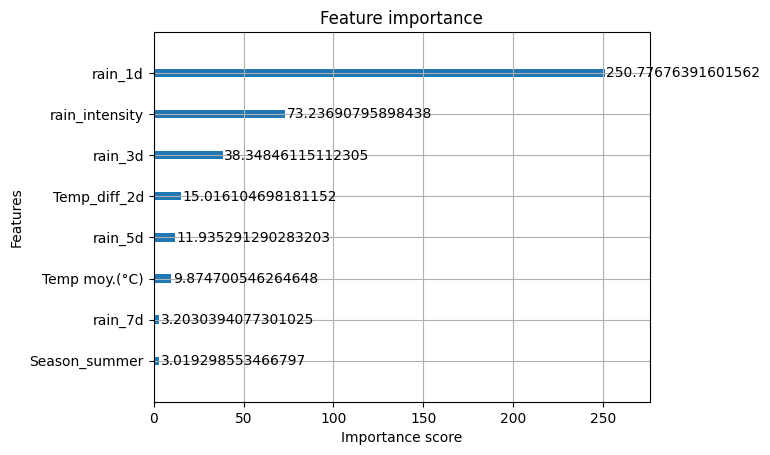

In [15]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

# Fit your model
xgb_model = models["XGBoost"]
xgb_model.fit(X_train, y_train)

# Plot feature importance
plot_importance(xgb_model, importance_type='gain')  # 'weight', 'gain', 'cover'
plt.show()

In [87]:
import joblib

# Suppose your trained model is models["XGBoost"]
xgb_model = models["XGBoost"]
xgb_model.fit(X_full, y_full)

# Save to disk
joblib.dump(xgb_model, "xgb_pluvial_flood_model.pkl")
print("Model saved!")

Model saved!


In [88]:
import shap
import numpy as np

# Train XGBoost on full data
# xgb_model = models["XGBoost"]
# xgb_model.fit(X_full, y_full)

xgb_model = joblib.load("../../server/app/models/xgb_pluvial_flood_model.pkl")

feature_names = list(X_full.columns)
avg_threshold = np.mean(best_thresholds_cv["XGBoost"])
explainer = shap.TreeExplainer(xgb_model)

def explain_predictions(indices, label):
    X_selected = X_full.iloc[indices]
    dates_selected = df.iloc[indices]["Date/Heure"]
    shap_values = explainer.shap_values(X_selected)

    print(f"  {label} ({len(indices)} cases)")

    for i, date in enumerate(dates_selected):
        row = X_selected.iloc[[i]]
        proba = xgb_model.predict_proba(row)[0, 1]
        prediciton_label = "FLOOD" if proba >= avg_threshold else "NO FLOOD"
        print(f"\n {date.date()}  |  Prob: {proba:.3f}  |  {prediciton_label}")

        row_shap = shap_values[i]
        row_values = row.values[0]
        # Sort features by absolute SHAP impact
        for j in np.argsort(np.abs(row_shap))[::-1]:
            impact = row_shap[j]
            val = row_values[j]
            direction = "⬆ increases" if impact > 0 else "⬇ decreases"
            print(f"  {feature_names[j]:<30} {val:>8.3f} | Impact: {impact:>8.3f} ({direction} flood risk)")


flood_cases  = np.where(y_full.values == 1)[0]
explain_predictions(flood_cases, "FLOOD CASES")
rng = np.random.default_rng(42)
no_flood_cases = rng.choice(np.where(y_full.values == 0)[0], size=11, replace=False)
explain_predictions(no_flood_cases, "NON-FLOOD CASES")

  FLOOD CASES (11 cases)

 2016-08-16  |  Prob: 0.997  |  FLOOD
  rain_1d                          69.000 | Impact:    3.814 (⬆ increases flood risk)
  rain_intensity                    0.569 | Impact:   -1.916 (⬇ decreases flood risk)
  rain_5d                         120.300 | Impact:    1.574 (⬆ increases flood risk)
  Temp_diff_2d                     -0.600 | Impact:   -0.941 (⬇ decreases flood risk)
  Season_summer                     1.000 | Impact:   -0.186 (⬇ decreases flood risk)
  rain_3d                          84.800 | Impact:    0.176 (⬆ increases flood risk)
  rain_7d                         120.300 | Impact:    0.051 (⬆ increases flood risk)
  Temp moy.(°C)                    21.000 | Impact:    0.044 (⬆ increases flood risk)
  Season_winter                     0.000 | Impact:    0.000 (⬇ decreases flood risk)
  Season_spring                     0.000 | Impact:    0.000 (⬇ decreases flood risk)
  is_freezing                       0.000 | Impact:    0.000 (⬇ decreases fl

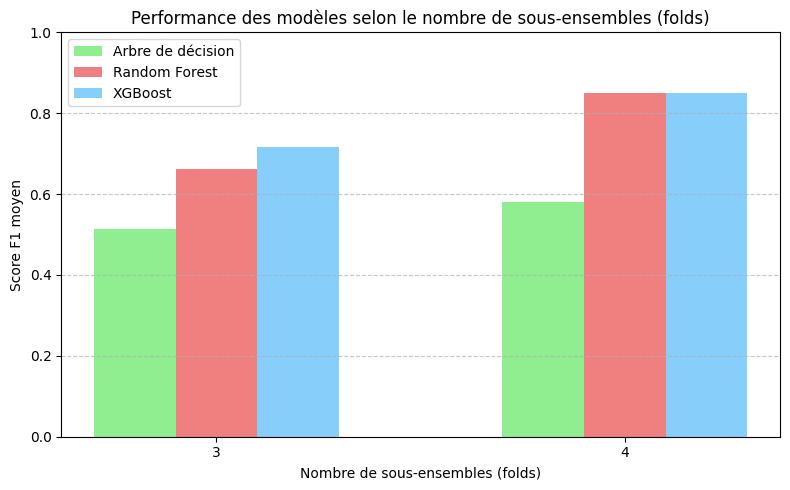

In [82]:
import matplotlib.pyplot as plt
import numpy as np

# Données
folds = [3, 4]  # nombre de splits
modeles = ["Arbre de décision", "Random Forest", "XGBoost"]

# Scores F1 correspondants (moyenne)
scores = {
    "Arbre de décision": [0.514, 0.581],
    "Random Forest": [0.662, 0.850],
    "XGBoost": [0.717, 0.850]
}

# Couleurs des barres
couleurs = ["lightgreen", "lightcoral", "lightskyblue"]

# Paramètres pour les barres
largeur_barre = 0.2
x = np.arange(len(folds))  # positions des groupes sur l'axe X

# Création du plot
plt.figure(figsize=(8,5))

for i, modele in enumerate(modeles):
    plt.bar(x + i*largeur_barre, scores[modele], width=largeur_barre, 
            label=modele, color=couleurs[i])

# Labels et titres
plt.xticks(x + largeur_barre, [str(f) for f in folds])
plt.xlabel("Nombre de sous-ensembles (folds)")
plt.ylabel("Score F1 moyen")
plt.title("Performance des modèles selon le nombre de sous-ensembles (folds)")
plt.ylim(0,1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Affichage
plt.tight_layout()
plt.show()

In [27]:
import optuna
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from optuna.pruners import MedianPruner

# -----------------------------
# 1. Prepare Data
# -----------------------------
X_full = pd.get_dummies(X, columns=["Season"], drop_first=True)
y_full = y
X_full = X_full.reindex(columns=X_full.columns, fill_value=0)

n_splits = 4
tscv = StratifiedTimeSeriesSplit(n_splits=n_splits)

# -----------------------------
# 2. Define objective functions
# -----------------------------
def objective_dt(trial):
    # f1_scores = []
    pr_auc_scores = []

    
    max_depth = trial.suggest_int("max_depth", 3, 15)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        class_weight="balanced",
        random_state=42
    )
    
    for train_idx, test_idx in tscv.split(y_full):
        X_train, X_test = X_full.iloc[train_idx], X_full.iloc[test_idx]
        y_train, y_test = y_full.iloc[train_idx], y_full.iloc[test_idx]
        
        # if y_test.sum() == 0:  # skip folds with no positives
        #     continue
        
        model.fit(X_train, y_train)
        y_pred_proba = model.predict_proba(X_test)[:, 1]

        pr_auc_scores.append(average_precision_score(y_test, y_pred_proba))

        trial.report(np.mean(pr_auc_scores), step=len(pr_auc_scores))
        if trial.should_prune():
            raise optuna.TrialPruned()

        
        # thresholds = np.linspace(0, 1, 50)
        # f1_fold = [f1_score(y_test, (y_pred_proba >= t).astype(int)) for t in thresholds]
        # f1_scores.append(max(f1_fold))

        # # Report intermediate value to pruner
        # trial.report(np.mean(f1_scores), step=len(f1_scores))
        # if trial.should_prune():
        #     raise optuna.TrialPruned()
    
    return np.mean(pr_auc_scores)


def objective_rf(trial):
    pr_auc_scores = []
    
    n_estimators = trial.suggest_int("n_estimators", 200, 1500, step=100)
    max_depth = trial.suggest_int("max_depth", 5, 25)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
    
    for train_idx, test_idx in tscv.split(y_full):
        X_train, X_test = X_full.iloc[train_idx], X_full.iloc[test_idx]
        y_train, y_test = y_full.iloc[train_idx], y_full.iloc[test_idx]
        
        # if y_test.sum() == 0:
        #     continue
        
        model.fit(X_train, y_train)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        # thresholds = np.linspace(0, 1, 50)
        # f1_fold = [f1_score(y_test, (y_pred_proba >= t).astype(int)) for t in thresholds]
        # f1_scores.append(max(f1_fold))

        # # Report intermediate value to pruner
        # trial.report(np.mean(f1_scores), step=len(f1_scores))
        # if trial.should_prune():
        #     raise optuna.TrialPruned()

        pr_auc_scores.append(average_precision_score(y_test, y_pred_proba))

        trial.report(np.mean(pr_auc_scores), step=len(pr_auc_scores))
        if trial.should_prune():
            raise optuna.TrialPruned()


    
    return np.mean(pr_auc_scores)


def objective_xgb(trial):
    # f1_scores = []
    pr_auc_scores = []

    
    n_estimators = trial.suggest_int("n_estimators", 300, 1000, step=50)
    max_depth = trial.suggest_int("max_depth", 3, 15)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3)
    subsample = trial.suggest_float("subsample", 0.5, 1.0)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0)
    min_child_weight = trial.suggest_int("min_child_weight", 1, 10)
    gamma = trial.suggest_float("gamma", 0, 5)
    
    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        min_child_weight=min_child_weight,
        gamma=gamma,
        scale_pos_weight=len(y_full[y_full==0])/len(y_full[y_full==1]),
        random_state=42,
        eval_metric="auc",
        n_jobs=-1
    )
    
    for train_idx, test_idx in tscv.split(y_full):
        X_train, X_test = X_full.iloc[train_idx], X_full.iloc[test_idx]
        y_train, y_test = y_full.iloc[train_idx], y_full.iloc[test_idx]
        
        # if y_test.sum() == 0:
        #     continue
        
        model.fit(X_train, y_train)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        # thresholds = np.linspace(0, 1, 50)
        # f1_fold = [f1_score(y_test, (y_pred_proba >= t).astype(int)) for t in thresholds]
        # f1_scores.append(max(f1_fold))

        # # Report intermediate value to pruner
        # trial.report(np.mean(f1_scores), step=len(f1_scores))
        # if trial.should_prune():
        #     raise optuna.TrialPruned()

        pr_auc_scores.append(average_precision_score(y_test, y_pred_proba))

        trial.report(np.mean(pr_auc_scores), step=len(pr_auc_scores))
        if trial.should_prune():
            raise optuna.TrialPruned()

    
    return np.mean(pr_auc_scores)

# -----------------------------
# 3. Run Optuna
# -----------------------------
pruner = MedianPruner(n_warmup_steps=5)

study_dt = optuna.create_study(direction="maximize", pruner=pruner)
study_dt.optimize(objective_dt, n_trials=100, show_progress_bar=True)

study_rf = optuna.create_study(direction="maximize", pruner=pruner)
study_rf.optimize(objective_rf, n_trials=100, show_progress_bar=True)

study_xgb = optuna.create_study(direction="maximize", pruner=pruner)
study_xgb.optimize(objective_xgb, n_trials=100, show_progress_bar=True)


# -----------------------------
# 4. Best params
# -----------------------------
print("Decision Tree Best Params:", study_dt.best_params)
print("Random Forest Best Params:", study_rf.best_params)
print("XGBoost Best Params:", study_xgb.best_params)
print("Decision Tree Best Value:", study_dt.best_value)
print("Random Forest Best Value:", study_rf.best_value)
print("XGBoost Best Value:", study_xgb.best_value)

[I 2026-02-26 11:04:27,649] A new study created in memory with name: no-name-e1e00c15-4df0-4908-bb39-3eadf441cfc1
Best trial: 1. Best value: 0.293531:   2%|▏         | 2/100 [00:00<00:08, 10.93it/s]

[I 2026-02-26 11:04:27,744] Trial 0 finished with value: 0.2591153217214817 and parameters: {'max_depth': 14, 'min_samples_split': 6, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.2591153217214817.
[I 2026-02-26 11:04:27,831] Trial 1 finished with value: 0.2935307954774463 and parameters: {'max_depth': 10, 'min_samples_split': 6, 'min_samples_leaf': 6}. Best is trial 1 with value: 0.2935307954774463.
[I 2026-02-26 11:04:27,910] Trial 2 finished with value: 0.2935307954774463 and parameters: {'max_depth': 15, 'min_samples_split': 8, 'min_samples_leaf': 6}. Best is trial 1 with value: 0.2935307954774463.


Best trial: 5. Best value: 0.342449:   6%|▌         | 6/100 [00:00<00:07, 12.45it/s]

[I 2026-02-26 11:04:27,990] Trial 3 finished with value: 0.2838007264253434 and parameters: {'max_depth': 6, 'min_samples_split': 8, 'min_samples_leaf': 8}. Best is trial 1 with value: 0.2935307954774463.
[I 2026-02-26 11:04:28,067] Trial 4 finished with value: 0.2935307954774463 and parameters: {'max_depth': 4, 'min_samples_split': 5, 'min_samples_leaf': 6}. Best is trial 1 with value: 0.2935307954774463.
[I 2026-02-26 11:04:28,142] Trial 5 finished with value: 0.3424486550548151 and parameters: {'max_depth': 9, 'min_samples_split': 7, 'min_samples_leaf': 2}. Best is trial 5 with value: 0.3424486550548151.


Best trial: 7. Best value: 0.398004:   8%|▊         | 8/100 [00:00<00:07, 12.55it/s]

...

Best trial: 7. Best value: 0.398004:  88%|████████▊ | 88/100 [00:07<00:01, 11.54it/s]

[I 2026-02-26 11:04:35,288] Trial 86 finished with value: 0.3980042106103706 and parameters: {'max_depth': 15, 'min_samples_split': 6, 'min_samples_leaf': 1}. Best is trial 7 with value: 0.3980042106103706.
[I 2026-02-26 11:04:35,373] Trial 87 finished with value: 0.3980042106103706 and parameters: {'max_depth': 13, 'min_samples_split': 10, 'min_samples_leaf': 1}. Best is trial 7 with value: 0.3980042106103706.
[W 2026-02-26 11:04:35,417] Trial 88 failed with parameters: {'max_depth': 11, 'min_samples_split': 3, 'min_samples_leaf': 2} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\yanis\AppData\Local\Programs\Python\Python314\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\yanis\AppData\Local\Temp\ipykernel_23248\186609609.py", line 49, in objective_dt
    pr_auc_scores.append(average_precision_score(y_test, y_pred_proba))
                         ~~~~~~~~~

Best trial: 7. Best value: 0.398004:  88%|████████▊ | 88/100 [00:07<00:01, 11.22it/s]


[W 2026-02-26 11:04:35,491] Trial 88 failed with value None.


KeyboardInterrupt: 

In [28]:
import optuna
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from optuna.pruners import MedianPruner

# -----------------------------
# 1. Prepare Data
# -----------------------------
X_full = pd.get_dummies(X, columns=["Season"], drop_first=True)
y_full = y
X_full = X_full.reindex(columns=X_full.columns, fill_value=0)

n_splits = 4
tscv = StratifiedTimeSeriesSplit(n_splits=n_splits)

def objective_xgb(trial):
    # f1_scores = []
    pr_auc_scores = []

    
    n_estimators = trial.suggest_int("n_estimators", 300, 1000, step=50)
    max_depth = trial.suggest_int("max_depth", 3, 15)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3)
    subsample = trial.suggest_float("subsample", 0.5, 1.0)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.5, 1.0)
    min_child_weight = trial.suggest_int("min_child_weight", 1, 10)
    gamma = trial.suggest_float("gamma", 0, 5)
    
    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        min_child_weight=min_child_weight,
        gamma=gamma,
        scale_pos_weight=len(y_full[y_full==0])/len(y_full[y_full==1]),
        random_state=42,
        eval_metric="auc",
        n_jobs=-1
    )
    
    for train_idx, test_idx in tscv.split(y_full):
        X_train, X_test = X_full.iloc[train_idx], X_full.iloc[test_idx]
        y_train, y_test = y_full.iloc[train_idx], y_full.iloc[test_idx]
        
        # if y_test.sum() == 0:
        #     continue
        
        model.fit(X_train, y_train)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        # thresholds = np.linspace(0, 1, 50)
        # f1_fold = [f1_score(y_test, (y_pred_proba >= t).astype(int)) for t in thresholds]
        # f1_scores.append(max(f1_fold))

        # # Report intermediate value to pruner
        # trial.report(np.mean(f1_scores), step=len(f1_scores))
        # if trial.should_prune():
        #     raise optuna.TrialPruned()

        pr_auc_scores.append(average_precision_score(y_test, y_pred_proba))

        trial.report(np.mean(pr_auc_scores), step=len(pr_auc_scores))
        if trial.should_prune():
            raise optuna.TrialPruned()

    
    return np.mean(pr_auc_scores)

# -----------------------------
# 3. Run Optuna
# -----------------------------
pruner = MedianPruner(n_warmup_steps=5)

study_xgb = optuna.create_study(direction="maximize", pruner=pruner)
study_xgb.optimize(objective_xgb, n_trials=500, show_progress_bar=True)


# -----------------------------
# 4. Best params
# -----------------------------
print("XGBoost Best Params:", study_xgb.best_params)
print("XGBoost Best Value:", study_xgb.best_value)

[I 2026-02-26 11:04:44,471] A new study created in memory with name: no-name-80513b3b-13eb-4252-8c81-0a4746bbecda
Best trial: 0. Best value: 0.481031:   0%|          | 1/500 [00:01<10:17,  1.24s/it]

[I 2026-02-26 11:04:45,709] Trial 0 finished with value: 0.4810307954774463 and parameters: {'n_estimators': 500, 'max_depth': 8, 'learning_rate': 0.26936438329705686, 'subsample': 0.8297796912782662, 'colsample_bytree': 0.875041366774439, 'min_child_weight': 1, 'gamma': 3.2583203265043803}. Best is trial 0 with value: 0.4810307954774463.


Best trial: 1. Best value: 0.495015:   0%|          | 2/500 [00:02<11:09,  1.34s/it]

[I 2026-02-26 11:04:47,128] Trial 1 finished with value: 0.49501454902608727 and parameters: {'n_estimators': 650, 'max_depth': 15, 'learning_rate': 0.1583896708548994, 'subsample': 0.7852273495317612, 'colsample_bytree': 0.8946051490049081, 'min_child_weight': 1, 'gamma': 1.8425076888359926}. Best is trial 1 with value: 0.49501454902608727.


Best trial: 2. Best value: 0.510119:   1%|          | 3/500 [00:03<09:22,  1.13s/it]

...

[I 2026-02-26 11:10:51,353] Trial 497 finished with value: 0.6428781866281866 and parameters: {'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.1390959697282853, 'subsample': 0.5546922969741785, 'colsample_bytree': 0.983344291387324, 'min_child_weight': 8, 'gamma': 0.47505686659390917}. Best is trial 362 with value: 0.7558712121212121.


Best trial: 362. Best value: 0.755871: 100%|█████████▉| 499/500 [06:07<00:00,  1.81it/s]

[I 2026-02-26 11:10:51,885] Trial 498 finished with value: 0.7266025641025642 and parameters: {'n_estimators': 300, 'max_depth': 9, 'learning_rate': 0.1500473473127543, 'subsample': 0.5815878211211308, 'colsample_bytree': 0.991278445638505, 'min_child_weight': 8, 'gamma': 0.2800093784942955}. Best is trial 362 with value: 0.7558712121212121.


Best trial: 362. Best value: 0.755871: 100%|██████████| 500/500 [06:07<00:00,  1.36it/s]

[I 2026-02-26 11:10:52,372] Trial 499 finished with value: 0.5091199103837911 and parameters: {'n_estimators': 300, 'max_depth': 14, 'learning_rate': 0.12064732876088148, 'subsample': 0.7936779160338605, 'colsample_bytree': 0.9696796383557408, 'min_child_weight': 8, 'gamma': 0.392130698292117}. Best is trial 362 with value: 0.7558712121212121.
XGBoost Best Params: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1569576844362741, 'subsample': 0.5996774358054417, 'colsample_bytree': 0.9993433435418904, 'min_child_weight': 8, 'gamma': 0.0003997346301727739}
XGBoost Best Value: 0.7558712121212121


In [29]:
print("XGBoost Best Params:", study_xgb.best_params)
print("XGBoost Best Value:", study_xgb.best_value)

XGBoost Best Params: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1569576844362741, 'subsample': 0.5996774358054417, 'colsample_bytree': 0.9993433435418904, 'min_child_weight': 8, 'gamma': 0.0003997346301727739}
XGBoost Best Value: 0.7558712121212121


In [66]:
print("Decision Tree Best Params:", study_dt.best_params)
print("Random Forest Best Params:", study_rf.best_params)
print("XGBoost Best Params:", study_xgb.best_params)
print("Decision Tree Best Value:", study_dt.best_value)
print("Random Forest Best Value:", study_rf.best_value)
print("XGBoost Best Value:", study_xgb.best_value)

Decision Tree Best Params: {'max_depth': 13, 'min_samples_split': 9, 'min_samples_leaf': 4}
Random Forest Best Params: {'n_estimators': 700, 'max_depth': 13, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2'}
XGBoost Best Params: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.29670916354962723, 'subsample': 0.7027709240441847, 'colsample_bytree': 0.8631961549641242, 'min_child_weight': 3, 'gamma': 4.7459357806153175}
Decision Tree Best Value: 0.5809523809523809
Random Forest Best Value: 0.85
XGBoost Best Value: 0.85


--- Decision Tree ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       811
           1       0.67      0.67      0.67         3

    accuracy                           1.00       814
   macro avg       0.83      0.83      0.83       814
weighted avg       1.00      1.00      1.00       814

ROC AUC: 0.8327168105219893
PR AUC: 0.44567294567294563


--- Random Forest ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       811
           1       1.00      1.00      1.00         3

    accuracy                           1.00       814
   macro avg       1.00      1.00      1.00       814
weighted avg       1.00      1.00      1.00       814

ROC AUC: 1.0
PR AUC: 1.0


--- XGBoost ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       811
           1       0.43      1.00      0.60         3

    accuracy                         

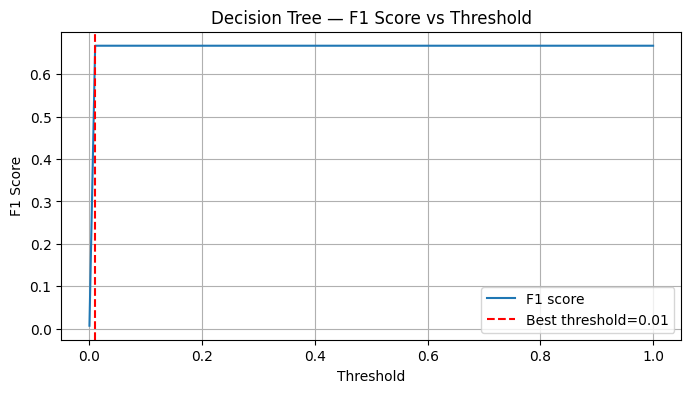

Random Forest: Best threshold = 0.55, F1 = 1.000


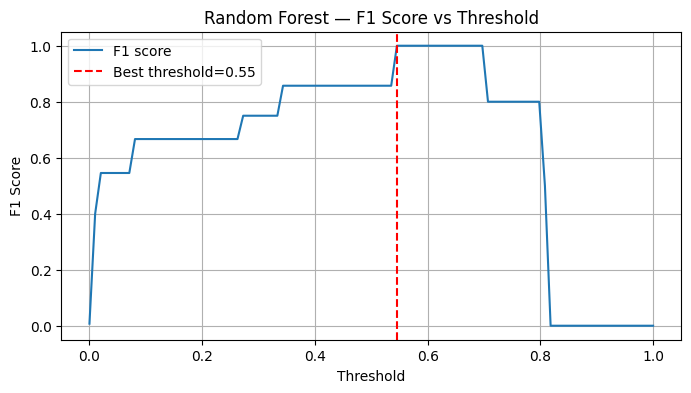

XGBoost: Best threshold = 0.94, F1 = 0.750


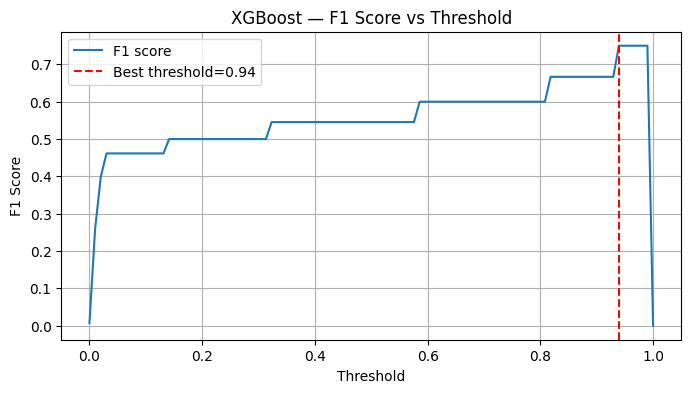

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

# -----------------------------
# 1. Preprocessing
# -----------------------------
df = weather_df.copy()

# Filter out days where mean temp <= 0
# df.loc[df["Temp moy.(°C)"] <= 0, "Inondation pluviale"] = 0

# Add season
df["Month"] = df["Date/Heure"].dt.month
def get_season(month):
    if month in [12, 1, 2]: return "winter"
    if month in [3, 4, 5]: return "spring"
    if month in [6, 7, 8]: return "summer"
    return "fall"

df["Season"] = df["Month"].apply(get_season)

# Compute rolling rain features
df = df.sort_values("Date/Heure").reset_index(drop=True)
df["rain_1d"] = df["Précip. tot. (mm)"]
df["rain_3d"] = df["Précip. tot. (mm)"].rolling(3, min_periods=1).sum()
df["rain_5d"] = df["Précip. tot. (mm)"].rolling(5, min_periods=1).sum()
df["rain_7d"] = df["Précip. tot. (mm)"].rolling(7, min_periods=1).sum()
df["rain_intensity"] = df["rain_1d"] / (df["rain_7d"] + 1)
df["is_freezing"] = (df["Temp moy.(°C)"] <= 0).astype(int)

# Temperature difference
df["Temp_diff_2d"] = df["Temp moy.(°C)"].diff(2)
df = df.dropna(subset=["Temp_diff_2d"])

# -----------------------------
# 2. Features & Target
# -----------------------------
features = [
    "Temp moy.(°C)", "rain_1d", "rain_3d", "rain_5d", "rain_7d",
    "Temp_diff_2d", "Season", "rain_intensity", "is_freezing"
]
X = df[features]
y = df["Inondation pluviale"]

# Train/test split
split_index = int(len(df) * 0.8)
X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]
X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

# One-hot encode season
X_train = pd.get_dummies(X_train, columns=["Season"], drop_first=True)
X_test = pd.get_dummies(X_test, columns=["Season"], drop_first=True)

# Ensure same columns
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# -----------------------------
# 3. Models
# -----------------------------
models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=9, min_samples_leaf=3, min_samples_split=6,
        class_weight="balanced", random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=1000, max_depth=None, min_samples_leaf=2, min_samples_split=4,
        max_features="sqrt", class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=625, max_depth=9, learning_rate=0.18356705912454613, 
        subsample=0.6042432475259683, colsample_bytree=0.9142952156084071, 
        min_child_weight=7, gamma=2.43394623300268,
        scale_pos_weight=len(y[y==0])/len(y[y==1]),
        random_state=42, eval_metric="auc", n_jobs=-1
    )
}

# -----------------------------
# 4. Train & Evaluate
# -----------------------------
threshold = 0.6
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    results[name] = y_pred_proba
    print(f"--- {name} ---")
    y_pred = (y_pred_proba >= threshold).astype(int)
    print(classification_report(y_test, y_pred))
    print("ROC AUC:", roc_auc_score(y_test, y_pred_proba))
    print("PR AUC:", average_precision_score(y_test, y_pred_proba))
    print("\n")

# -----------------------------
# 5. Threshold Analysis
# -----------------------------
from sklearn.metrics import f1_score

thresholds = np.linspace(0, 1, 100)
best_thresholds = {}

for name, y_pred_proba in results.items():
    f1_scores = []
    for t in thresholds:
        y_pred = (y_pred_proba >= t).astype(int)
        f1_scores.append(f1_score(y_test, y_pred))
    
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_thresholds[name] = best_threshold
    
    print(f"{name}: Best threshold = {best_threshold:.2f}, F1 = {f1_scores[best_idx]:.3f}")
    
    # Plot F1 vs Threshold
    plt.figure(figsize=(8,4))
    plt.plot(thresholds, f1_scores, label="F1 score")
    plt.axvline(best_threshold, color="red", linestyle="--", label=f"Best threshold={best_threshold:.2f}")
    plt.title(f"{name} — F1 Score vs Threshold")
    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.grid(True)
    plt.show()


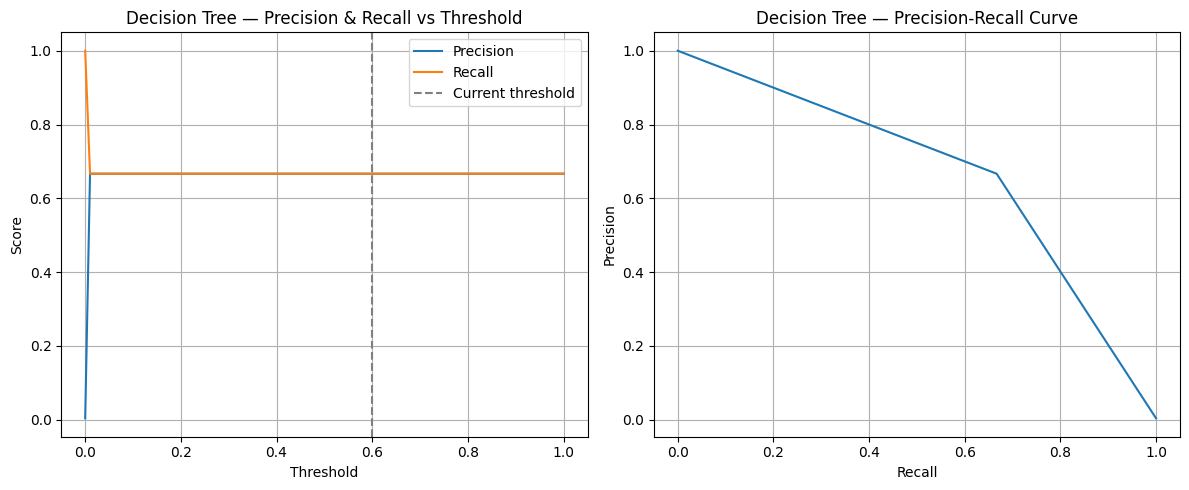

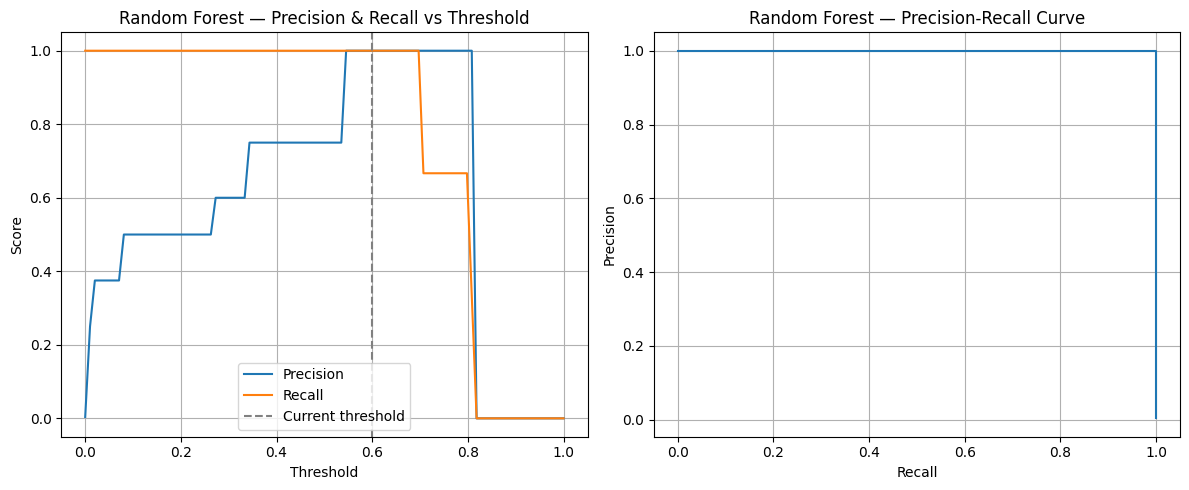

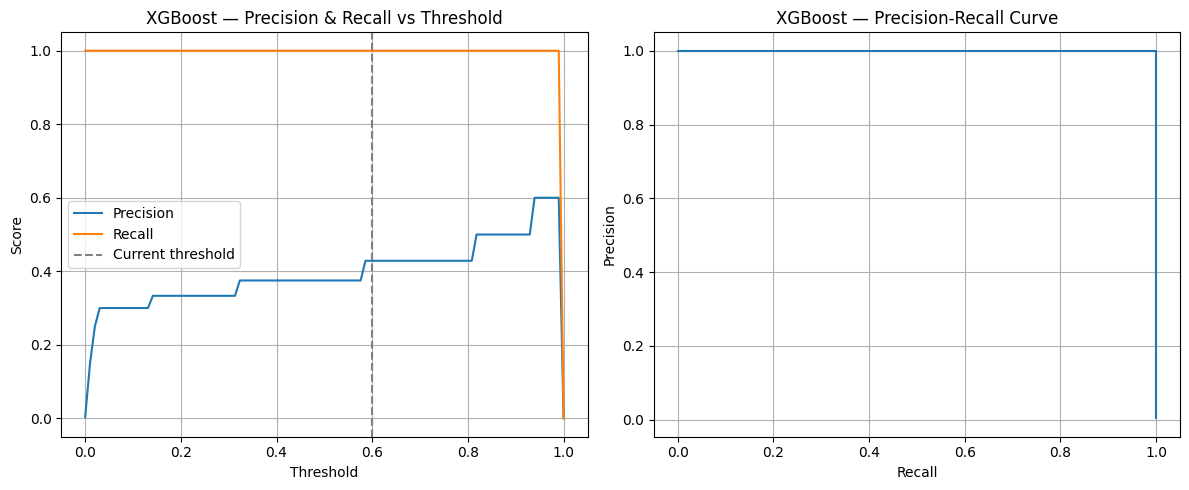

In [37]:
from sklearn.metrics import precision_score, recall_score, precision_recall_curve

thresholds = np.linspace(0, 1, 100)

# -----------------------------
# Graphs for each model
# -----------------------------
for name, y_pred_proba in results.items():

    # Precision and Recall vs Threshold
    precision_scores = []
    recall_scores = []

    for t in thresholds:
        y_pred = (y_pred_proba >= t).astype(int)

        precision_scores.append(
            precision_score(y_test, y_pred, zero_division=0)
        )
        recall_scores.append(
            recall_score(y_test, y_pred, zero_division=0)
        )

    plt.figure(figsize=(12,5))

    # Plot Precision & Recall vs Threshold
    plt.subplot(1,2,1)
    plt.plot(thresholds, precision_scores, label="Precision")
    plt.plot(thresholds, recall_scores, label="Recall")
    plt.axvline(0.6, color="gray", linestyle="--", label="Current threshold")
    plt.title(f"{name} — Precision & Recall vs Threshold")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True)


    # Plot Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)

    plt.subplot(1,2,2)
    plt.plot(recall, precision)
    plt.title(f"{name} — Precision-Recall Curve")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [38]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[811   0]
 [  3   0]]


In [61]:
import joblib

# Suppose your trained model is models["XGBoost"]
xgb_model = models["XGBoost"]

# Save to disk
joblib.dump(xgb_model, "xgb_flood_model.pkl")
print("Model saved!")

Model saved!


In [63]:
import joblib
from xgboost import XGBClassifier

# Load
xgb_model = joblib.load("xgb_flood_model.pkl")

# Now you can predict
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
print(y_pred_proba)

[2.32827515e-04 7.76004570e-04 3.82077851e-04 7.76004570e-04
 3.35637335e-04 4.54899622e-04 3.35637335e-04 2.03589007e-04
 2.03589007e-04 7.76004570e-04 2.32827515e-04 7.82474468e-04
 2.03589007e-04 2.03589007e-04 2.32827515e-04 2.03589007e-04
 2.32827515e-04 2.32827515e-04 1.28279949e-04 1.00160897e-01
 2.32827515e-04 2.03589007e-04 2.03589007e-04 7.76004570e-04
 7.76004570e-04 4.79416020e-04 2.32827515e-04 8.80278312e-05
 2.05782964e-03 7.76004570e-04 8.87376140e-04 2.63746537e-04
 7.82474468e-04 3.83834238e-04 2.03589007e-04 4.48359549e-03
 5.84413414e-04 4.54899622e-04 1.00671656e-04 2.45521334e-03
 2.03589007e-04 1.65218968e-04 8.80278312e-05 8.80278312e-05
 7.82474468e-04 7.82474468e-04 2.03589007e-04 2.07320729e-04
 5.48244570e-04 7.76004570e-04 8.87376140e-04 5.12369967e-04
 3.35637335e-04 3.83834238e-04 3.17777204e-03 2.03589007e-04
 7.76004570e-04 7.76004570e-04 4.07083862e-04 2.07320729e-04
 2.03589007e-04 2.96667044e-04 8.80278312e-05 9.97196621e-05
 7.82474468e-04 2.866536

In [23]:
import optuna
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
from xgboost import XGBClassifier

n_repeats = 20  # number of repeated splits for stability

def objective(trial):
    # Suggest hyperparameters
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "random_state": 42,
        "eval_metric": "auc",
        "n_jobs": -1
    }
    
    pr_aucs = []
    
    for i in range(n_repeats):
        # repeated random 0.8/0.2 splits
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, stratify=y, random_state=42+i
        )
        
        model = XGBClassifier(**params, scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]))
        model.fit(X_train, y_train)
        
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        pr_aucs.append(average_precision_score(y_test, y_pred_proba))
    
    # return the mean PR AUC across repeats
    return np.mean(pr_aucs)

# Create study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)  # number of Optuna trials

print("Best PR AUC:", study.best_value)
print("Best hyperparameters:", study.best_params)

[I 2026-02-19 11:08:18,894] A new study created in memory with name: no-name-1351580b-2d94-4461-ad10-39ab1c9f9f05
[I 2026-02-19 11:08:33,700] Trial 0 finished with value: 0.7541932035972283 and parameters: {'n_estimators': 1507, 'max_depth': 6, 'learning_rate': 0.2899123789586013, 'subsample': 0.7617349450592057, 'colsample_bytree': 0.892020812418201, 'min_child_weight': 3, 'gamma': 3.501283202837649}. Best is trial 0 with value: 0.7541932035972283.
[I 2026-02-19 11:08:47,366] Trial 1 finished with value: 0.7561009485094852 and parameters: {'n_estimators': 1388, 'max_depth': 9, 'learning_rate': 0.15785938190960427, 'subsample': 0.9422083069418772, 'colsample_bytree': 0.7651969361761197, 'min_child_weight': 4, 'gamma': 3.5236782209791295}. Best is trial 1 with value: 0.7561009485094852.
[I 2026-02-19 11:09:03,967] Trial 2 finished with value: 0.7342738444351348 and parameters: {'n_estimators': 1662, 'max_depth': 9, 'learning_rate': 0.02809417664407754, 'subsample': 0.9266335695631805, '

Best PR AUC: 0.8387847222222222
Best hyperparameters: {'n_estimators': 1152, 'max_depth': 3, 'learning_rate': 0.2213389889789979, 'subsample': 0.6071319576839203, 'colsample_bytree': 0.6947768244476361, 'min_child_weight': 10, 'gamma': 2.017762742578622}


In [28]:
X.head()

,Temp moy.(°C),rain_1d,rain_3d,rain_5d,rain_7d,Temp_diff_2d,rain_intensity,Season_spring,Season_summer,Season_winter
2,-12.8,14.6,15.7,15.7,15.7,-7.6,0.874251,False,False,True
3,-2.4,26.2,40.9,41.9,41.9,6.8,0.610723,False,False,True
4,-11.6,0.0,40.8,41.9,41.9,1.2,0.000000,False,False,True
5,-13.8,2.1,28.3,43.0,44.0,-11.4,0.046667,False,False,True
6,-17.6,3.2,5.3,46.1,47.2,-6.0,0.066390,False,False,True


In [29]:
import optuna
import numpy as np
from sklearn.metrics import average_precision_score
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit

# One-hot encode Season
# X_encoded = pd.get_dummies(X, columns=["Season"], drop_first=True)

# Replace X with encoded version
# X = X_encoded

def objective(trial):

    # Define hyperparameters
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "random_state": 42,
        "eval_metric": "auc",
        "n_jobs": -1
    }

    tscv = TimeSeriesSplit(n_splits=5)
    pr_aucs = []

    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Skip fold if no positive cases in test
        if y_test.sum() == 0:
            continue

        # Safe scale_pos_weight
        n_pos = y_train.sum()
        n_neg = len(y_train) - n_pos

        if n_pos == 0:
            continue

        scale_pos_weight = n_neg / n_pos
        model = XGBClassifier(
            **params,
            scale_pos_weight=scale_pos_weight
        )
        model.fit(X_train, y_train)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        pr_auc = average_precision_score(y_test, y_pred_proba)
        pr_aucs.append(pr_auc)

    # If no valid folds, return worst possible score
    if len(pr_aucs) == 0:
        return 0

    return np.mean(pr_aucs)

# Run Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

print("Best PR AUC:", study.best_value)
print("Best hyperparameters:", study.best_params)


[I 2026-02-19 16:58:20,584] A new study created in memory with name: no-name-500a98c8-7816-40de-8674-eb81b0f4c087
[I 2026-02-19 16:58:21,692] Trial 0 finished with value: 0.7704081632653063 and parameters: {'n_estimators': 788, 'max_depth': 9, 'learning_rate': 0.20236884072839964, 'subsample': 0.9118841997483398, 'colsample_bytree': 0.8526597318176569, 'min_child_weight': 2, 'gamma': 0.24773808917954665}. Best is trial 0 with value: 0.7704081632653063.
[I 2026-02-19 16:58:22,965] Trial 1 finished with value: 0.7291666666666666 and parameters: {'n_estimators': 1032, 'max_depth': 3, 'learning_rate': 0.21855302284562186, 'subsample': 0.8373836598671899, 'colsample_bytree': 0.9865066514002853, 'min_child_weight': 7, 'gamma': 2.196891453000953}. Best is trial 0 with value: 0.7704081632653063.
[I 2026-02-19 16:58:24,724] Trial 2 finished with value: 0.7514792899408285 and parameters: {'n_estimators': 1741, 'max_depth': 8, 'learning_rate': 0.26112914774823787, 'subsample': 0.8857165496638213,

Best PR AUC: 0.808130081300813
Best hyperparameters: {'n_estimators': 1629, 'max_depth': 6, 'learning_rate': 0.21178095967688468, 'subsample': 0.724677383713105, 'colsample_bytree': 0.8116820604361982, 'min_child_weight': 10, 'gamma': 1.2535370283554754}


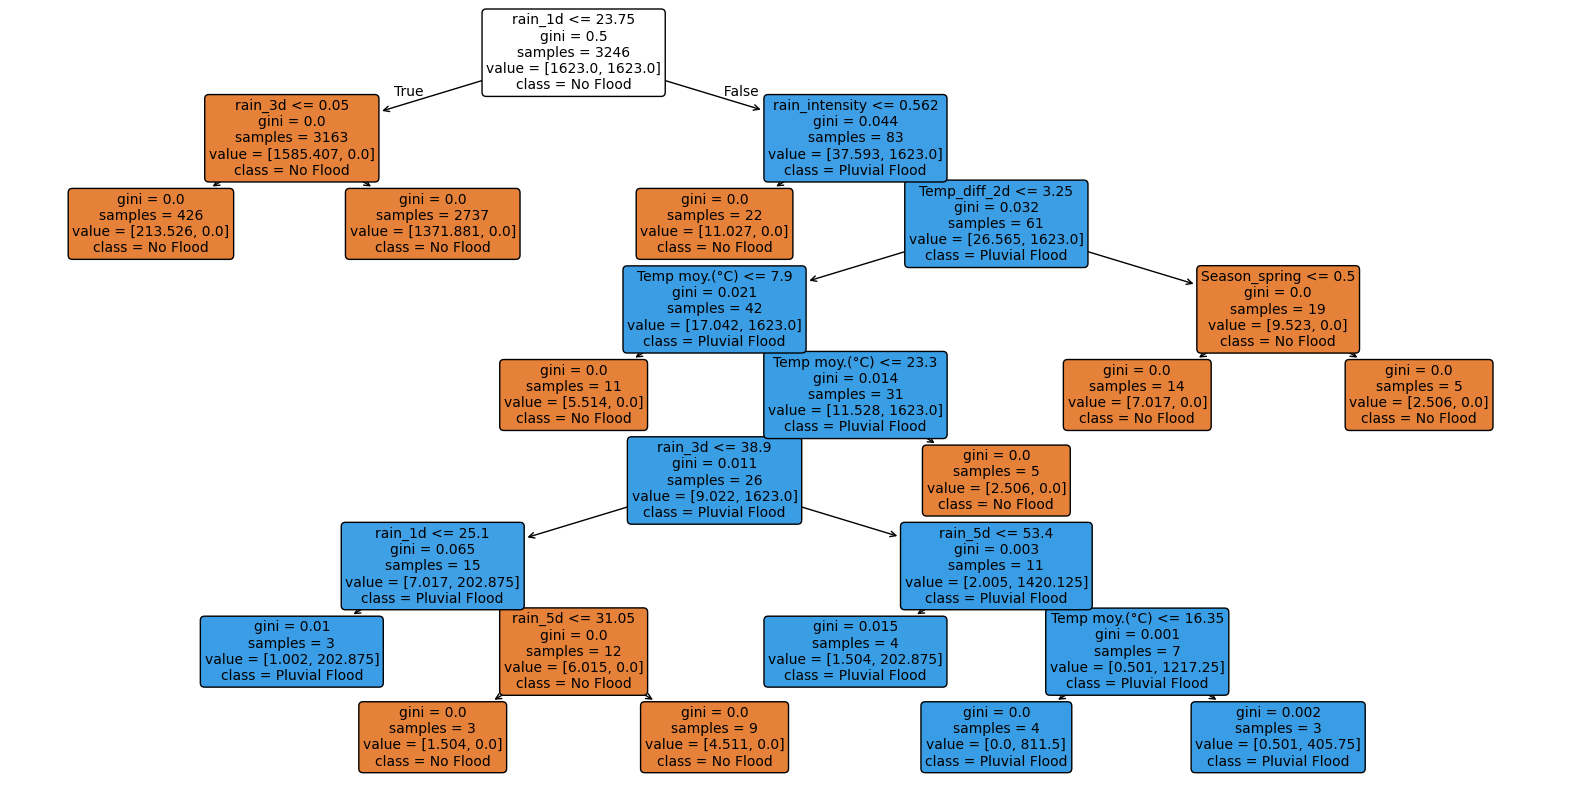

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Decision Tree model from your dictionary
dt_model = models["Decision Tree"]

# Feature names (after one-hot encoding)
features = X_train.columns.tolist()

plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=features,
    class_names=["No Flood", "Pluvial Flood"],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()


In [224]:
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats

param_dist = {
    "max_depth": stats.randint(3, 10),
    "min_samples_split": stats.randint(2, 10),
    "min_samples_leaf": stats.randint(1, 10),
    "max_features": [None, "sqrt", "log2"]
}

tree = DecisionTreeClassifier(class_weight="balanced", random_state=42)

# Use ROC-AUC as scoring because dataset is highly imbalanced
rand_search = RandomizedSearchCV(
    tree,
    param_distributions=param_dist,
    n_iter=700,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

rand_search.fit(X_train, y_train)

# Best hyperparameters
print("Best params:", rand_search.best_params_)
print("Best ROC-AUC:", rand_search.best_score_)

# Train best model
best_tree = rand_search.best_estimator_
y_pred_proba = best_tree.predict_proba(X_test)[:, 1]


Best params: {'max_depth': 9, 'max_features': None, 'min_samples_leaf': 3, 'min_samples_split': 6}
Best ROC-AUC: 0.9496469547117368
